# Student Social Media and Mental Health Impact

## Project Overview

This project analyzes the relationship between social media usage, student lifestyle habits, academic activity, and mental health. The Python notebook focuses on preparing and exploring the dataset, while the cleaned data is used to create interactive visualizations and dashboards in Tableau.

The analysis examines social media platforms, daily usage, number of daily unlocks, purpose of use, study hours, physical activity, sleep, academic level, gender, age, stress, and mental health scores.

## Project Workflow

1. Load and inspect the dataset
2. Check and remove duplicate records
3. Check for missing values
4. Explore distributions and descriptive statistics
5. Analyze social media usage patterns
6. Explore relationships between social media usage and student lifestyle/mental-health measures
7. Perform correlation analysis
8. Prepare the cleaned dataset for Tableau visualization

## Main Tools

- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook
- Tableau

## Tableau

The Tableau workbook contains three main dashboards:

- **Overview**
- **Social Media & Mental Health**
- **Student Segments**

The workbook also contains supporting worksheets for platform distribution, usage, stress, sleep, study hours, academic level, student segments, and mental-health scores.


## 1. Import Libraries


In [168]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset


In [169]:
df = pd.read_csv("Student Social Media And Mental Health Impact.csv")

## 3. Preview the Dataset


In [170]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


## 4. Inspect Dataset Structure and Data Types


In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


## 5. Check for Duplicate Rows


In [172]:
df.duplicated().sum()

np.int64(2)

## 6. Display Duplicate Records


In [176]:
df[df.duplicated(keep = False)]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
886,19,Female,Other,Undergraduate,LinkedIn,Education,6.1,202,1.0,2.1,5.8,High,4.1
1870,21,Male,USA,Undergraduate,Snapchat,Entertainment,3.9,126,5.1,2.6,7.1,Low,7.5
2405,19,Female,Other,Undergraduate,LinkedIn,Education,6.1,202,1.0,2.1,5.8,High,4.1
2463,21,Male,USA,Undergraduate,Snapchat,Entertainment,3.9,126,5.1,2.6,7.1,Low,7.5


## 7. Remove Duplicate Records


In [177]:
df = df.drop_duplicates()

## 8. Verify Duplicate Removal


In [178]:
df.duplicated().sum()

np.int64(0)

## 9. Check for Missing Values


In [179]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

## 10. Detect Potential Outliers in Daily Unlocks


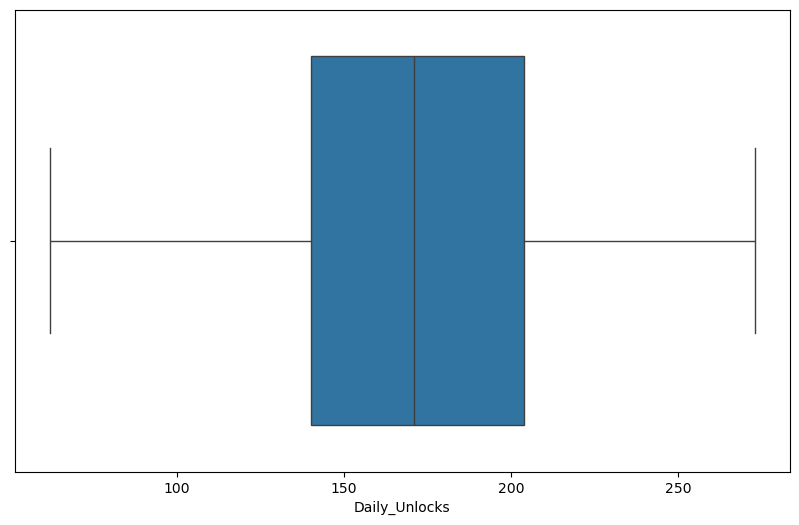

In [58]:
plt.figure(figsize = (10 , 6))

sns.boxplot(x = "Daily_Unlocks", data = df)
plt.show()

## 11. Generate Descriptive Statistics


In [50]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.750760,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.668406,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


## 12. Analyze Most-Used Social Media Platforms


In [61]:
df["Most_Used_Platform"].value_counts()

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      522
YouTube       491
Twitter       462
Snapchat      419
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

## 13. Visualize Platform Distribution


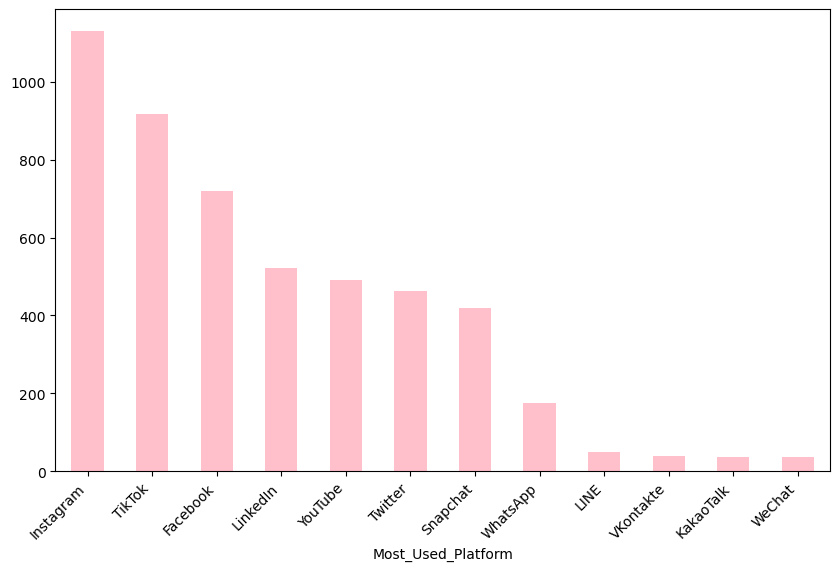

In [109]:
plt.figure(figsize = (10, 6))

df["Most_Used_Platform"].value_counts().plot(kind = "bar", color = "pink")

plt.xticks(rotation = 45, ha = "right")

plt.show()

## 14. Analyze Purpose of Social Media Use


In [70]:
df["Purpose_Of_Use"].value_counts()

Purpose_Of_Use
Entertainment    2551
Education        1093
Networking        793
News              561
Name: count, dtype: int64

## 15. Visualize Purpose of Use


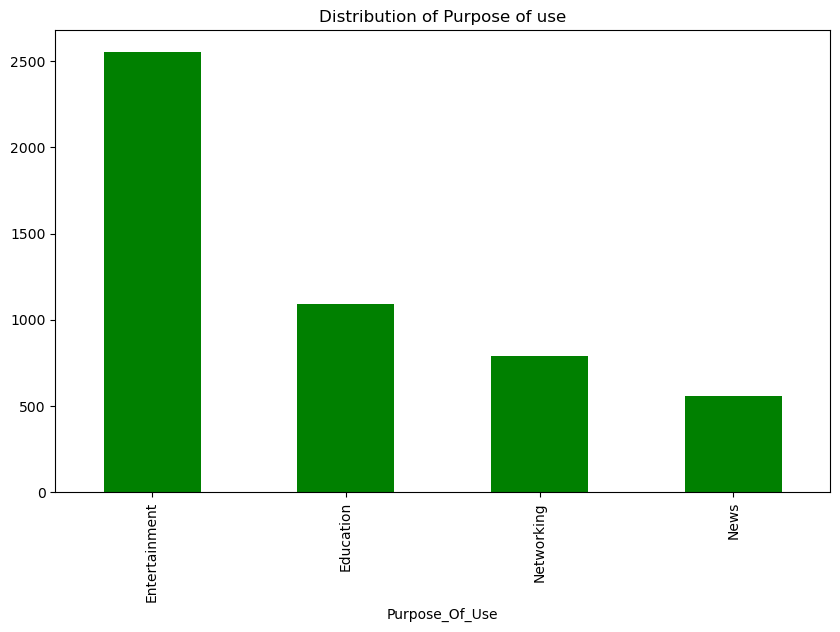

In [108]:
plt.figure(figsize = (10, 6))

df["Purpose_Of_Use"].value_counts().plot(kind = "bar", color = "green")
plt.title("Distribution of Purpose of use")

plt.show()

## 16. Compare Average Daily Usage by Platform


In [69]:
df.groupby("Most_Used_Platform")["Avg_Daily_Usage_Hours"].mean().sort_values(ascending = False)

Most_Used_Platform
WhatsApp     6.434857
TikTok       5.259477
Snapchat     5.258234
Twitter      5.155628
YouTube      5.152342
WeChat       4.961111
Facebook     4.929346
Instagram    4.923009
LinkedIn     4.830077
KakaoTalk    4.813889
VKontakte    4.177500
LINE         3.312000
Name: Avg_Daily_Usage_Hours, dtype: float64

## 17. Analyze Mental Health Scores by Gender


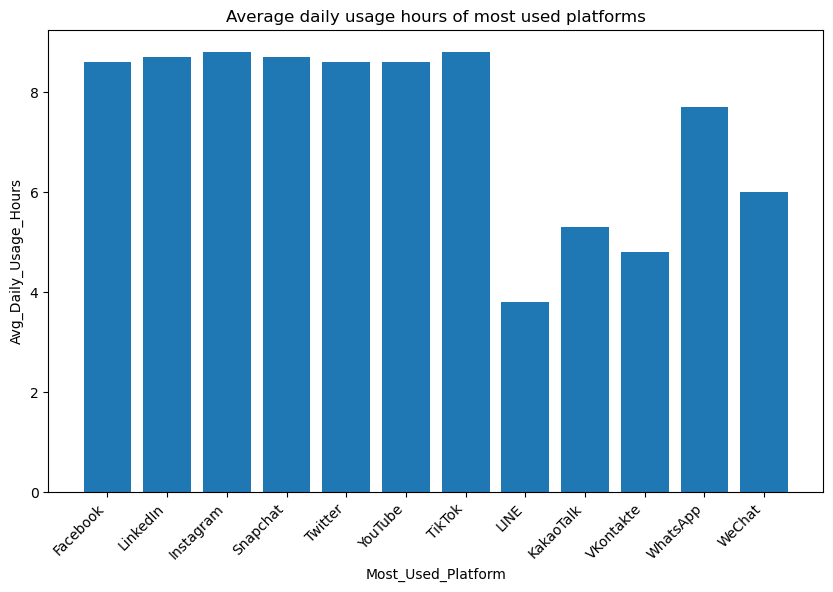

In [105]:
plt.figure(figsize = (10, 6))

plt.bar(df["Most_Used_Platform"], df["Avg_Daily_Usage_Hours"])

plt.title("Average daily usage hours of most used platforms")
plt.xlabel("Most_Used_Platform")
plt.ylabel("Avg_Daily_Usage_Hours")
plt.xticks(rotation = 45, ha = "right")

plt.show()

## 18. Visualize Mental Health Scores by Gender


In [101]:
gender_mental_health = df.groupby("Gender")["Mental_Health_Score"].sum().sort_values(ascending = False)
gender_mental_health

Gender
Male      16519.2
Female    14624.1
Name: Mental_Health_Score, dtype: float64

## 19. Analyze Academic Level and Gender


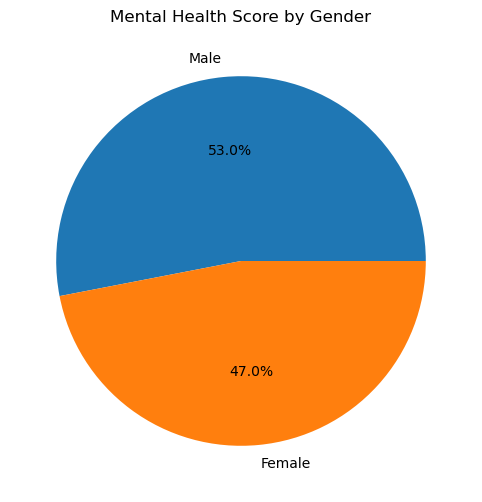

In [110]:
plt.figure(figsize = (10, 6))

plt.pie(gender_mental_health , labels = gender_mental_health.index, autopct = "%1.1f%%")
plt.title("Mental Health Score by Gender")

plt.show()

## 20. Visualize Academic Level by Gender


In [131]:
academic_lvl = df.groupby("Academic_Level")["Gender"].value_counts()
academic_lvl

Academic_Level  Gender
Graduate        Male       489
                Female     429
High School     Male       274
                Female     176
Undergraduate   Male      1871
                Female    1759
Name: count, dtype: int64

## 21. Analyze Social Media Usage vs. Study Hours


<Figure size 1000x600 with 0 Axes>

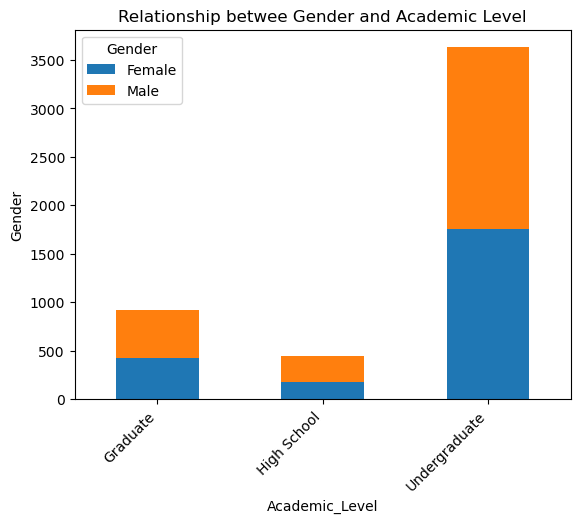

In [140]:
plt.figure(figsize = (10, 6))

df.groupby("Academic_Level")["Gender"].value_counts().unstack().plot(kind = "bar", stacked = True)

plt.title("Relationship betwee Gender and Academic Level")
plt.xlabel("Academic_Level")
plt.ylabel("Gender")
plt.xticks(rotation = 45, ha = "right")

plt.show()

## 22. Analyze Social Media Usage vs. Physical Activity


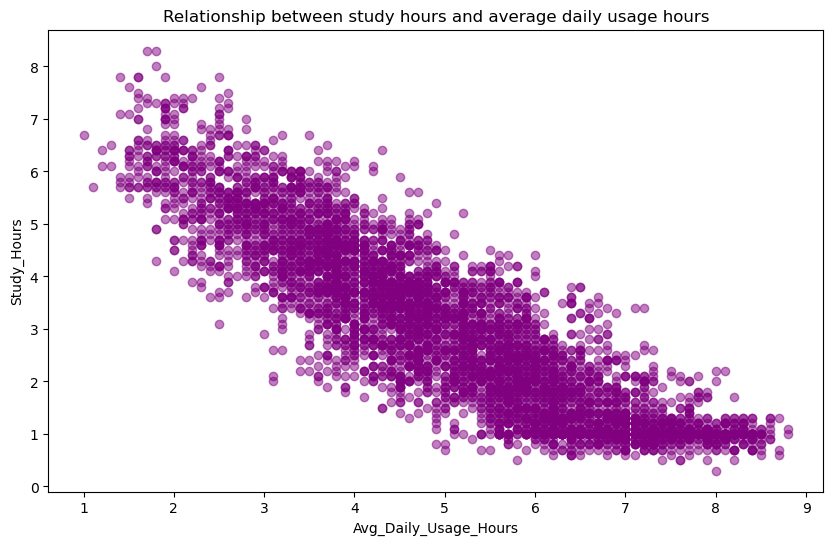

In [143]:
plt.figure(figsize = (10, 6))

plt.scatter(df["Avg_Daily_Usage_Hours"], df["Study_Hours"], alpha = 0.5, color = "purple")

plt.title("Relationship between study hours and average daily usage hours")
plt.xlabel("Avg_Daily_Usage_Hours")
plt.ylabel("Study_Hours")


plt.show()

## 23. Analyze Social Media Usage vs. Sleep


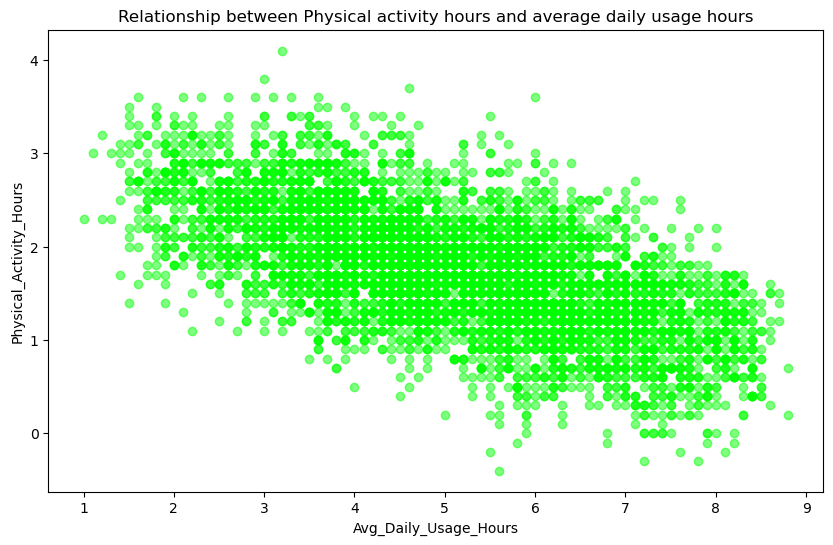

In [122]:
plt.figure(figsize = (10, 6))

plt.scatter(df["Avg_Daily_Usage_Hours"], df["Physical_Activity_Hours"], alpha = 0.5, color = "lime")

plt.title("Relationship between Physical activity hours and average daily usage hours")
plt.xlabel("Avg_Daily_Usage_Hours")
plt.ylabel("Physical_Activity_Hours")

plt.show()

## 24. Analyze Median Age by Gender


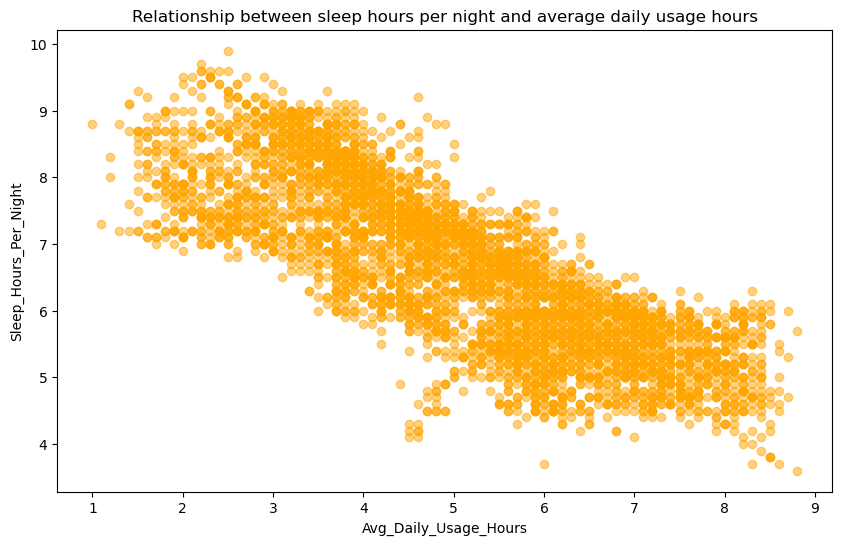

In [121]:
plt.figure(figsize = (10, 6))

plt.scatter(df["Avg_Daily_Usage_Hours"], df["Sleep_Hours_Per_Night"], alpha = 0.5, color = "orange")

plt.title("Relationship between sleep hours per night and average daily usage hours")
plt.xlabel("Avg_Daily_Usage_Hours")
plt.ylabel("Sleep_Hours_Per_Night")

plt.show()

## 25. Correlation Analysis


In [129]:
df.groupby("Gender")["Age"].median()

Gender
Female    20.0
Male      21.0
Name: Age, dtype: float64

## 26. Prepare Cleaned Dataset for Tableau


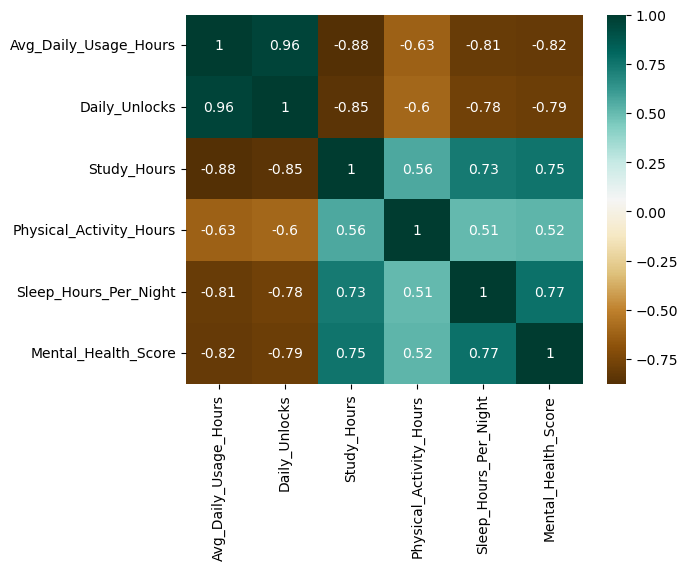

In [166]:
corr_matrix = df[["Avg_Daily_Usage_Hours", "Daily_Unlocks", "Study_Hours", "Physical_Activity_Hours", "Sleep_Hours_Per_Night", "Mental_Health_Score"]].corr()

sns.heatmap(corr_matrix, annot =True, cmap = "BrBG")
plt.show()

## 26. Prepare Cleaned Dataset for Tableau


In [1]:
#df.to_csv("Student Social Media And Mental Health Impact 1.csv")